In [236]:
import pandas as pd
import os, sys, re
import numpy as np
import torch.nn as nn
from sklearn.feature_selection import SelectKBest, f_regression
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
import copy
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


# Import Dataset and Tidy

In [237]:
train_data = pd.read_csv("./data/covid.train.csv")
test_data = pd.read_csv("./data/covid.test.csv")

In [238]:
test_data

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,shop.2,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,52.071090,8.624001,29.374792,5.391413,2.754804,19.695098,13.685645,24.747837,66.194950,44.873473
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,58.742461,21.720187,41.375784,9.450179,3.150088,22.075715,17.302077,23.559622,57.015009,38.372829
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59.109045,20.123959,40.072556,8.781522,2.888209,23.920870,18.342506,24.993341,55.291498,38.907257
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.442267,16.083529,36.977612,5.199286,2.575347,21.073800,12.087171,18.608723,67.036197,43.142779
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.588783,19.503010,42.631236,11.549771,8.530551,15.896575,11.781634,15.065228,61.196518,43.574676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,56.762931,21.494159,44.202567,14.996865,2.291745,17.740003,12.822676,18.123344,60.417531,37.156229
889,889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.888461,16.770893,37.373472,7.169675,2.631595,20.587449,15.960166,23.710310,58.758735,38.673787
890,890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.589848,16.761311,36.874822,11.046907,1.912310,16.800220,13.280423,22.423640,60.934851,43.122513
891,891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.966384,22.696669,45.350415,20.343487,2.385330,16.528265,15.092539,17.476063,54.862386,44.016255


In [239]:
train_data

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2,tested_positive.2
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.812411,43.430423,16.151527,1.602635,15.409449,12.088688,16.702086,53.991549,43.604229,20.704935
1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.682974,43.196313,16.123386,1.641863,15.230063,11.809047,16.506973,54.185521,42.665766,21.292911
2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.593983,43.362200,16.159971,1.677523,15.717207,12.355918,16.273294,53.637069,42.972417,21.166656
3,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.576992,42.954574,15.544373,1.578030,15.295650,12.218123,16.045504,52.446223,42.907472,19.896607
4,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.091433,43.290957,15.214655,1.641667,14.778802,12.417256,16.134238,52.560315,43.321985,20.178428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,2695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.090116,30.839219,7.849525,1.760094,14.617563,11.163213,18.742673,68.024690,38.920206,13.008853
2696,2696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.779264,30.617100,7.754800,1.780730,14.513419,11.281241,18.539741,67.855755,39.224244,12.725638
2697,2697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.961085,30.595194,7.744075,1.921828,14.160990,11.163526,18.702564,67.731162,38.740651,12.613441
2698,2698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.609582,30.420998,7.687974,1.992580,14.409427,11.330301,19.134697,67.795100,38.595125,12.477227


## Baseline 0
先用 sklearn 快速確認「資料整理 + 評估流程」都正確。

In [240]:
# 從 training dataset 中分離出 validation dataset
X = train_data.drop(columns=['id', 'tested_positive.2'])
y = train_data['tested_positive.2'] # day3 percentage
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 標準化
scaler = StandardScaler() # 建立一個「標準化器」
X_train_s = scaler.fit_transform(X_train)

# 沿用上方平均數與標準差來校正 val
X_val_s = scaler.transform(X_val)


# ------------------------------------
# baseline 0 (如果我們預測出來 day3 = day2，loss 會是多少？)
pred_b0 = X_val["tested_positive.1"].to_numpy(dtype=np.float64) 
loss_b0 = mean_squared_error(y_val, pred_b0)
print(f"MSE of baseline 0 (predict y3=y2): {loss_b0}")

MSE of baseline 0 (predict y3=y2): 1.0638112270372913


# Baseline 1
建立 Ridge MODEL（y = wx+b），alpha 是懲罰 ｗ 機制，讓 w 不要太大 -> alpha 越小，model 越接近線性模型，擬合更貼但更可能 overfit；alpha 越大，model 越保守較不容易 overfit


In [241]:
# 測試不同 alpha 的 model

best_alpha_loss = {"alpha":0, "loss":10}

for a in list(np.arange(0.01, 2.0001, 0.01)):
    model = Ridge(alpha=a)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_val_s)
    loss = mean_squared_error(y_val, pred)
    if loss < best_alpha_loss["loss"] and loss < loss_b0:
        best_alpha_loss["alpha"] = a
        best_alpha_loss["loss"] = loss

print(f"best alpha: {best_alpha_loss['alpha']}, MSE of baseline 1: {best_alpha_loss['loss']}")

best alpha: 0.01, MSE of baseline 1: 0.9291660509752497


# PyTorch

### helper functions

In [242]:
def set_seed(seed: int, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# 下面開始是 current notebook 會用到的 helper。
def make_multi_loader(*tensors, batch_size: int, seed: int):
    """Build a reproducible DataLoader for training batches."""
    g = torch.Generator()
    g.manual_seed(seed)

    dataset = TensorDataset(*tensors)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=0,
    )


def make_flat_mlp(input_dim, hidden=64, dropout=0.1, n_layers=2):
    """Build a flat MLP for the residual prediction head."""
    layers = []
    dim = input_dim
    for _ in range(max(1, n_layers)):
        layers.extend([
            nn.Linear(dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        ])
        dim = hidden
    layers.append(nn.Linear(dim, 1))
    net = nn.Sequential(*layers)
    nn.init.zeros_(net[-1].weight)
    nn.init.zeros_(net[-1].bias)
    return net


class FlatResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden=64, dropout=0.1, n_layers=2):
        super().__init__()
        self.net = make_flat_mlp(input_dim, hidden=hidden, dropout=dropout, n_layers=n_layers)

    def forward(self, x):
        return self.net(x)


def build_selectkbest_flat_inputs(
    X_train,
    X_val,
    y_train,
    non_base_cols,
    baseline_col,
    k,
):
    """Select top-k non-baseline features, scale them, and append the baseline input."""
    k = min(k, len(non_base_cols))
    selector = SelectKBest(score_func=f_regression, k=k)
    X_train_sel = selector.fit_transform(X_train[non_base_cols], y_train)
    X_val_sel = selector.transform(X_val[non_base_cols])

    selected_cols = [
        col for col, keep in zip(non_base_cols, selector.get_support()) if keep
    ]

    feature_scaler = StandardScaler()
    X_train_sel_s = feature_scaler.fit_transform(X_train_sel).astype(np.float32)
    X_val_sel_s = feature_scaler.transform(X_val_sel).astype(np.float32)

    baseline_scaler = StandardScaler()
    base_train_raw = X_train[[baseline_col]].to_numpy(dtype=np.float32)
    base_val_raw = X_val[[baseline_col]].to_numpy(dtype=np.float32)
    base_train_in_s = baseline_scaler.fit_transform(base_train_raw).astype(np.float32)
    base_val_in_s = baseline_scaler.transform(base_val_raw).astype(np.float32)

    X_train_final_s = np.hstack([X_train_sel_s, base_train_in_s])
    X_val_final_s = np.hstack([X_val_sel_s, base_val_in_s])

    return {
        'selector': selector,
        'selected_cols': selected_cols,
        'feature_scaler': feature_scaler,
        'baseline_scaler': baseline_scaler,
        'X_train_final_s': X_train_final_s,
        'X_val_final_s': X_val_final_s,
        'base_train_raw': base_train_raw,
        'base_val_raw': base_val_raw,
        'base_train_in_s': base_train_in_s,
        'base_val_in_s': base_val_in_s,
    }

# Flat Residual MLP (SelectKBest + raw baseline add-back)

In [243]:
X = train_data.drop(columns=['id', 'tested_positive.2'])
y_day3 = train_data['tested_positive.2']
y = y_day3 - train_data['tested_positive.1'] # residual target: day3 - day2
X_train, X_val, y_train, y_val, y_train_day3, y_val_day3 = train_test_split(X, y, y_day3, test_size=0.2, random_state=42)

# 目標仍然是預測 residual：day3 - day2。
# baseline column 不進 SelectKBest，因為它要保留給 raw add-back。
ALL_INPUT_COLS = X_train.columns.tolist()
BASELINE_COL = 'tested_positive.1'
NONBASE_COLS = [c for c in ALL_INPUT_COLS if c != BASELINE_COL]
SELECT_K = 16
base_train_raw = X_train[[BASELINE_COL]].to_numpy(dtype=np.float32)
base_val_raw = X_val[[BASELINE_COL]].to_numpy(dtype=np.float32)

print(f'total input columns = {len(ALL_INPUT_COLS)}')
print(f'non-baseline candidate columns = {len(NONBASE_COLS)}')
print(f'SelectKBest k = {SELECT_K}')
print(f'raw add-back baseline column = {BASELINE_COL}')

input dim = 93
raw add-back baseline column = tested_positive.1


## SelectKBest Summary

In [244]:
print(f'candidate non-baseline columns = {len(NONBASE_COLS)}')
print(f'SelectKBest keeps top k = {SELECT_K}')
print(f'baseline column kept for raw add-back = {BASELINE_COL}')
print('baseline is not passed through SelectKBest')

using all 93 input columns
baseline column kept for raw add-back: tested_positive.1
flat model sees the full ordered vector:
state columns -> day1 columns -> day2 columns -> day3 columns


## SelectKBest Features

In [245]:
# flat MLP 會吃進 top-k selected features，再額外拼上 baseline input。
INPUT_DIM = min(SELECT_K, len(NONBASE_COLS)) + 1
INPUT_DIM

93

## Select and Normalize

In [246]:
flat_inputs = build_selectkbest_flat_inputs(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    non_base_cols=NONBASE_COLS,
    baseline_col=BASELINE_COL,
    k=SELECT_K,
)

selector = flat_inputs['selector']
selected_feature_cols = flat_inputs['selected_cols']
feature_scaler = flat_inputs['feature_scaler']
baseline_scaler = flat_inputs['baseline_scaler']
X_train_flat_s = flat_inputs['X_train_final_s']
X_val_flat_s = flat_inputs['X_val_final_s']
base_tr_raw = flat_inputs['base_train_raw']
base_va_raw = flat_inputs['base_val_raw']
base_tr_in_s = flat_inputs['base_train_in_s']
base_va_in_s = flat_inputs['base_val_in_s']

print('selected features:')
print(selected_feature_cols)
print(f'X_train_flat_s shape = {X_train_flat_s.shape}')
print(f'X_val_flat_s shape = {X_val_flat_s.shape}')
print(f'raw baseline add-back shape = {base_tr_raw.shape}')


X_train_full_s shape = (2160, 93)
X_val_full_s shape = (540, 93)
raw baseline add-back shape = (2160, 1)


## Tensor And Training Loop (Flat MLP)

In [247]:
# flat MLP: top-k selected features + baseline input。
# 仍然保留 raw 的 day2 baseline 做最後 add-back，輸出才是 day3。
X_train_flat_t = torch.tensor(X_train_flat_s, dtype=torch.float32)
X_val_flat_t = torch.tensor(X_val_flat_s, dtype=torch.float32)
base_tr_raw_t = torch.tensor(base_tr_raw, dtype=torch.float32)
base_va_raw_t = torch.tensor(base_va_raw, dtype=torch.float32)
ytr_res_t = torch.tensor(y_train.to_numpy(dtype=np.float32), dtype=torch.float32).view(-1, 1)
ytr_day3_t = torch.tensor(y_train_day3.to_numpy(dtype=np.float32), dtype=torch.float32).view(-1, 1)
yva_day3_t = torch.tensor(y_val_day3.to_numpy(dtype=np.float32), dtype=torch.float32).view(-1, 1)



## ----------- model ----------- 
### initial parameters
seed = 2025
lr = 0.01
bs = 20
epochs = 50000
patience = 2000
bad_count = 0
dropout = 0.2
hidden = 32
n_layers = 2
weight_decay = 1e-4
train_hist, val_hist = [], []
best_epoch, best_state = None, None
best_va = float('inf')

set_seed(seed)
model = FlatResidualMLP(
    input_dim=X_train_flat_t.shape[1],
    hidden=hidden,
    dropout=dropout,
    n_layers=n_layers,
)

### training
opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr/100)
train_loader = make_multi_loader(
    X_train_flat_t,
    ytr_res_t,
    batch_size=bs,
    seed=seed,
)

for ep in range(epochs):
    model.train()
    
    for batch in train_loader:
        x_b, yb_res = batch

        pred_delta = model(x_b)
        mse = F.mse_loss(pred_delta, yb_res)
        loss = mse

        opt.zero_grad()
        loss.backward()
        opt.step()
    
    scheduler.step()

    with torch.no_grad():
        model.eval()

        p_tr_delta = model(X_train_flat_t)
        p_va_delta = model(X_val_flat_t)

        p_tr = p_tr_delta + base_tr_raw_t
        p_va = p_va_delta + base_va_raw_t

        tr_mse = F.mse_loss(p_tr, ytr_day3_t).item()
        va_mse = F.mse_loss(p_va, yva_day3_t).item()

        train_hist.append(tr_mse)
        val_hist.append(va_mse)
        print(f'epoch {ep + 1}: tr_mse={tr_mse:.4f}, va_mse={va_mse:.4f}')

        if va_mse < best_va - 1e-8:
            best_va = va_mse
            best_epoch = ep + 1
            best_state = copy.deepcopy(model.state_dict())
            bad_count = 0
        else:
            bad_count += 1
            if bad_count >= patience:
                print(f'Early stopping at epoch {ep + 1}. Best epoch = {best_epoch}, best va_mse = {best_va:.4f}')
                break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f'Restored best model from epoch {best_epoch} with best va_mse = {best_va:.4f}')



epoch 1: tr_mse=1.0370, va_mse=1.0469
epoch 2: tr_mse=1.0150, va_mse=1.0459
epoch 3: tr_mse=1.0208, va_mse=1.0549
epoch 4: tr_mse=0.9899, va_mse=1.0303
epoch 5: tr_mse=1.0023, va_mse=1.0554
epoch 6: tr_mse=0.9680, va_mse=1.0474
epoch 7: tr_mse=0.9598, va_mse=1.0704
epoch 8: tr_mse=0.9600, va_mse=1.0459
epoch 9: tr_mse=0.9660, va_mse=1.0539
epoch 10: tr_mse=0.9434, va_mse=1.0400
epoch 11: tr_mse=0.9578, va_mse=1.0203
epoch 12: tr_mse=0.9203, va_mse=1.0607
epoch 13: tr_mse=0.9436, va_mse=1.0142
epoch 14: tr_mse=0.9002, va_mse=1.0202
epoch 15: tr_mse=0.9075, va_mse=1.0088
epoch 16: tr_mse=0.8704, va_mse=1.0110
epoch 17: tr_mse=0.9128, va_mse=1.0108
epoch 18: tr_mse=0.8629, va_mse=0.9910
epoch 19: tr_mse=0.8742, va_mse=1.0356
epoch 20: tr_mse=0.8934, va_mse=1.0396
epoch 21: tr_mse=0.8820, va_mse=0.9839
epoch 22: tr_mse=0.8515, va_mse=0.9961
epoch 23: tr_mse=0.8225, va_mse=1.0047
epoch 24: tr_mse=0.8190, va_mse=1.0163
epoch 25: tr_mse=0.8276, va_mse=0.9959
epoch 26: tr_mse=0.8573, va_mse=1.

## Epoch Curve
訓練完成後，畫出 flat MLP 的 day3 train / validation MSE。


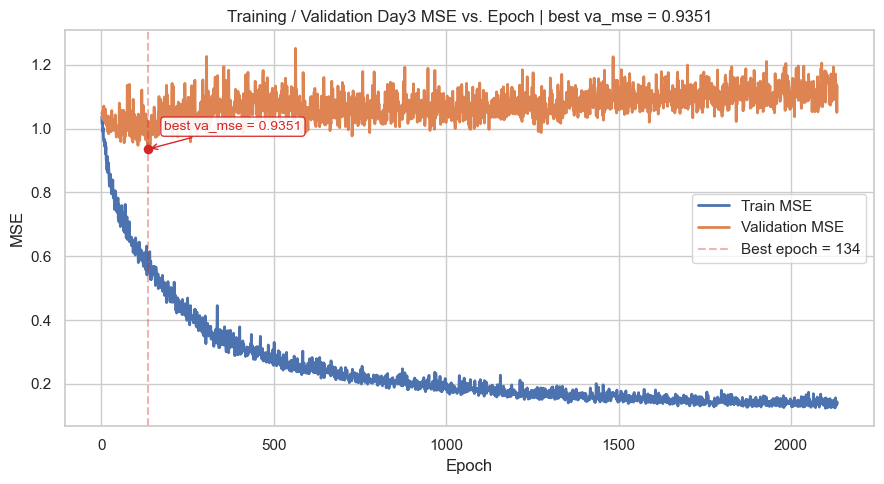

In [248]:
sns.set_theme(style="whitegrid")
epochs_ran = np.arange(1, len(train_hist) + 1)
best_epoch_plot = best_epoch if best_epoch is not None else int(np.argmin(val_hist) + 1)
best_va_mse = val_hist[best_epoch_plot - 1]

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, train_hist, label="Train MSE", linewidth=2)
plt.plot(epochs_ran, val_hist, label="Validation MSE", linewidth=2)
plt.axvline(best_epoch_plot, color="tab:red", linestyle="--", alpha=0.35, label=f"Best epoch = {best_epoch_plot}")
plt.scatter(best_epoch_plot, val_hist[best_epoch_plot - 1], color="tab:red", s=35, zorder=3)
plt.annotate(
    f'best va_mse = {best_va_mse:.4f}',
    xy=(best_epoch_plot, best_va_mse),
    xytext=(12, 14),
    textcoords='offset points',
    fontsize=10,
    color='tab:red',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:red', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='tab:red', lw=1),
)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title(f"Training / Validation Day3 MSE vs. Epoch | best va_mse = {best_va_mse:.4f}")
plt.legend()
plt.tight_layout()
plt.show()


# 實際預測、輸出 submission.csv，並上傳 kaggle

In [249]:
# 依照 data/sampleSubmission.csv 的格式產出 submission.csv
test_df = test_data.drop(columns=['id']).copy()
test_nonbase = test_df[NONBASE_COLS]
assert list(test_nonbase.columns) == NONBASE_COLS, 'Test columns do not match non-baseline training inputs.'

test_sel_s = feature_scaler.transform(selector.transform(test_nonbase)).astype(np.float32)
test_base_raw = test_df[[BASELINE_COL]].to_numpy(dtype=np.float32)
test_base_in_s = baseline_scaler.transform(test_base_raw).astype(np.float32)
test_flat_s = np.hstack([test_sel_s, test_base_in_s])
test_flat_t = torch.tensor(test_flat_s, dtype=torch.float32)
test_base_raw_t = torch.tensor(test_base_raw, dtype=torch.float32)
test_ids = test_data['id'].to_numpy()

model.eval()
with torch.no_grad():
    pred_delta = model(test_flat_t)
    pred_day3 = (pred_delta + test_base_raw_t).squeeze(1).cpu().numpy()

submission = pd.read_csv('./data/sampleSubmission.csv')
submission['id'] = test_ids
submission['tested_positive'] = pred_day3

submission.to_csv('submission.csv', index=False)

import subprocess
subprocess.run([
    'kaggle', 'competitions', 'submit',
    '-c', 'ml2021spring-hw1',
    '-f', 'submission.csv',
    '-m', 'flat MLP'
], check=True)
submission.head()

100%|██████████| 11.9k/11.9k [00:00<00:00, 13.7kB/s]


Successfully submitted to ML2021Spring-hw1

,id,tested_positive
0,0,20.361633
1,1,2.379711
2,2,2.613098
3,3,10.638544
4,4,2.367415
